---
---
## Trabajo Práctico 5 - Estimación de Intervalos

---
### Josefina Urquiza
---
---

Considerar $n=32$ lanzamientos de una moneda cargada con probabilidad $p$ de salir cara. El numero de caras $X$ es una variable aleatoria con distribucion binomial $X \sim B(n, p)$. Considerar
un tanda de lanzamientos en el que salen $k$ caras. El estimador del
parametro $p$ es $\hat{p} = \frac{k}{n}$. El intervalo de confianza estándar de $p$ con un nivel de confianza del $95\%$ es $\hat{p} \pm 1.96\sqrt{\hat{p}(1 − \hat{p})/n}$, donde $q = 1.96$ es el cuantil normal estandar para un $95\%$ CL.

  * Simular 10.000 tandas de lanzamientos asumiendo $p = 0.2$.

  * Verificar para cada tanda si el intervalo incluye o no a $p = 0.2$.

  * Estimar la cobertura del intervalo.

  * Decidir si el intervalo es exacto y comparar la cobertura con respecto al nivel de confianza.

  * Barrer $p$ en el intervalo [0,1] en pasos de $0.01$, graficar y ver si hay valores de $p$ para los cuáles la cobertura es particularmente mala.

  * Estimar la cobertura de un nuevo intervalo $t \pm 1.96 \sqrt{t(1 − t)/n}$ con $t = (k + 2)/(n + 4)$, equivalente a “agregar dos  aciertos y dos fracasos”.

In [2]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
import danatools
from numpy import linalg
print("Librerias ok")

Librerias ok


#### 1. Simular 10.000 tandas de lanzamientos asumiendo  𝑝 = 0.2

In [3]:
###  - Parámetros
# Número de lanzamientos
n = 32
# Probabilidad de obtener cara
p = 0.2 
# Número de simulaciones
nsimulaciones = 10000

# Generar una muestra de datos aleatorios con una distribución binomial
rng = np.random.default_rng(seed=6870)
data =  binom.rvs(n, p, size= nsimulaciones, random_state=rng)

# Mostramos algunos valores...
data[0:5]
#Corroboramos el eje
# len(data)

array([ 3, 10,  5,  9,  6], dtype=int64)

#### 2. Verificar para cada tanda si el intervalo incluye o no a  𝑝 = 0.2
Como en cada simulación se espera obtener un valor distinto de 𝑘, es necesario calcular un intervalo de confianza diferente para cada caso.
El estimador del parametro $p$ es $\hat{p} = \frac{k}{n}$.

In [4]:
#Cuantil normal estandar para un  95% CL.
q = 1.96

# Calcular el estimador de p y su intervalo de confianza para cada tanda de lanzamiento
estimador_p = data / n

#Corroboramos la longitud = 10000
# print("Longitud de estimador_p", len(estimador_p))

# Calcular límites del intervalo de confianza
limites = q * np.sqrt(estimador_p * (1 - estimador_p) / n)

# Calcular límites inferior y superior
limites_inferiores = estimador_p - limites
limites_superiores = estimador_p + limites

# Verificar si p=0.2 está dentro de cada intervalo
intervalo_si = (limites_inferiores <= p) & (limites_superiores >= p)

# Nos da como resultdos todos valores booleanos

# Transformamos a dataframe y contamos cuantos TRUE hay
df = pd.DataFrame(intervalo_si)
# El valor True nos dice cuantos intervalos incluye a 𝑝 = 0.2
print("Hay", len(df[df[0] == True]), " intervalos incluye a 𝑝 = 0.2")



Hay 8894  intervalos incluye a 𝑝 = 0.2


El resultado final muestra cuantos de los 10.000 intervalos de confianza incluyen el valor real de 𝑝 = 0.2. Comparar esta cantidad con el 95% esperado nos permite evaluar si el método utilizado para calcular los intervalos de confianza es preciso y si proporciona la cobertura adecuada. En este caso, obtuvimos 8894 intervalos que contienen el valor de p, lo cual es menor a los 9500 que se esperaría para una cobertura del 95%. Esto indica que el intervalo no está alcanzando la cobertura esperada. Mientras que si el conteo de intervalos que contienen  𝑝 = 0.2 estuviera cerca de 9500 de las 10.000 simulaciones, podríamos decir que el método de intervalo de confianza es adecuado y se ajusta al nivel de confianza del 95%.

#### 3. Estimar la cobertura del intervalo.
Se deben calcular dentro de las 10.000 simulaciones que porcentaje incluyeron el p=0.2
En este caso corroboramos, lo mencionado anteriormente, solo el 88.9% se ajusta. Si esta cobertura se aproxima al nivel de confianza del 95%, se está cumpliendo con la cobertura esperada. 

In [5]:
cobertura_intervalo = np.mean(intervalo_si)
print(f"Cobertura del intervalo de confianza: {cobertura_intervalo:.3f}")

Cobertura del intervalo de confianza: 0.889


In [6]:
# Ademas, Evaluamos la probabilidad de cobertura del intervalo aproximado:
# Cual es la diferencia con el calculo anteior?
import danatools
coverage, coverage_error = danatools.get_coverage(limites_inferiores,limites_superiores, estimador_p)
print(f"Coverage probability: {coverage:.4f} ± {coverage_error:.4f}")

Coverage probability: 0.9993 ± 0.0003


#### 3. Decidir si el intervalo es exacto y comparar la cobertura con respecto al nivel de confianza.
Para decidir hay que compararlo con el 95%. Donde vemos si la cobertura está cerca del 95%, podemos considerar el intervalo como exacto, ya que el intervalo de confianza cumple con el nivel de confianza nominal. Si la cobertura es. significativamente diferente del 95% (por ejemplo, si es mucho menor o mayor), indicaría que el intervalo no es exacto y que la construcción del intervalo no proporciona la cobertura esperada.

In [7]:
nivel_confianza = 0.95
# Calculamos la diferencia entre la cobertura y el nivel de confianza
diferencia = abs(cobertura_intervalo - nivel_confianza)

# Comentarios varios....
print(f"Cobertura observada del intervalo: {cobertura_intervalo:.4f}")
print(f"Diferencia respecto al 95% esperado: {diferencia:.4f}")
# Margen de tolerancia razonable, por ejemplo 1%
if diferencia < 0.01:  
    print("El intervalo es aproximadamente exacto.")
else:
    print("El intervalo no es exacto.")
# En resumen, si bien no es exacto, esta cerca del valor y tiene una diferencia de 0.061. Pero el intervalo no es exacto.

Cobertura observada del intervalo: 0.8894
Diferencia respecto al 95% esperado: 0.0606
El intervalo no es exacto.


#### 4. Barrer  𝑝 en el intervalo [0,1] en pasos de  0.01,  graficar y ver si hay valores de  𝑝  para los cuáles la cobertura es particularmente mala.

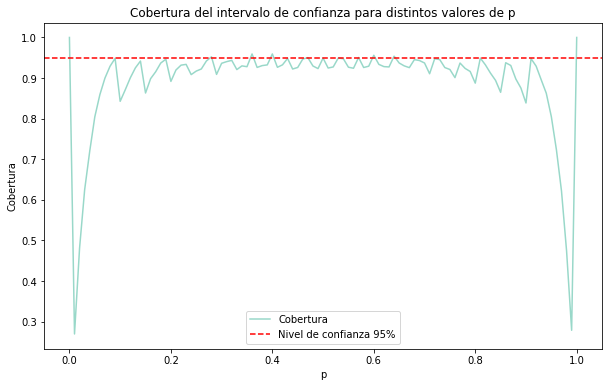

In [8]:
# Volvemos a setear los parámetros pero modificando p
# Número de lanzamientos
n = 32
# Número de tandas de lanzamientos
nsimulaciones = 10000
# Paso entre valores de p
paso_p = 0.01
# Calculamos cuantos valores de p se deben estimar entre 0-1 en pasos de 0.01
# Segun lo comentado en clase, usar linspace
num_p = np.linspace(0, 1, int(1 / paso_p) + 1)  

# Generación de simulaciones para cada valor de p de manera vectorizada 
# Es correcta esta forma para uno usar un for?
rng = np.random.default_rng(seed=6870)
resultados = binom.rvs(n, num_p[:, np.newaxis], size=(len(num_p), nsimulaciones), random_state=rng)

# Calcular estimador p para cada simulación
p_estimado = resultados / n

# Cálculo del margen de error y de los intervalos de confianza
margen_error = 1.96 * np.sqrt(p_estimado * (1 - p_estimado) / n)
limite_inferior = p_estimado - margen_error
limite_superior = p_estimado + margen_error

# Verificar si el valor verdadero de p está dentro del intervalo para cada valor de p y cada simulación
cobertura = np.mean((limite_inferior <= num_p[:, None]) & (num_p[:, None] <= limite_superior), axis=1)

## Corroborar...
# Graficar la cobertura en función de los valores de p
plt.figure(figsize=(10, 6))
plt.plot(num_p, cobertura, label='Cobertura', color='#99d8c9')
plt.axhline(0.95, color='r', linestyle='--', label='Nivel de confianza 95%')
plt.xlabel('p')
plt.ylabel('Cobertura')
plt.title('Cobertura del intervalo de confianza para distintos valores de p')
plt.legend()
plt.show()
